In [ ]:
from google.colab import drive
import zipfile
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to your dataset ZIP file
zip_path = "/content/drive/My Drive/Emotion.zip"  # Update with your actual path
extract_path = "/content/emotion_dataset"

# Unzip the dataset
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")


Mounted at /content/drive
Dataset extracted successfully!


In [ ]:
import os

# List files inside the extracted dataset
print("Contents of '/content/emotion_dataset':")
print(os.listdir("/content/emotion_dataset"))


Contents of '/content/emotion_dataset':
['Emotion']


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt


In [ ]:
print("Contents of '/content/emotion_dataset/Emotion':")
print(os.listdir("/content/emotion_dataset/Emotion"))


Contents of '/content/emotion_dataset/Emotion':
['test', 'train']


In [ ]:
train_dir = "/content/emotion_dataset/Emotion/train"
test_dir = "/content/emotion_dataset/Emotion/test"

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data Augmentation for Training Set
train_datagen = ImageDataGenerator(
    rescale=1.0/255,         # Normalize pixel values
    rotation_range=20,       # Rotate images up to 20 degrees
    width_shift_range=0.2,   # Shift images horizontally (20%)
    height_shift_range=0.2,  # Shift images vertically (20%)
    shear_range=0.2,         # Shear transformation
    zoom_range=0.2,          # Random zoom
    horizontal_flip=True,    # Flip images horizontally
    fill_mode='nearest'      # Fill missing pixels after transformation
)

# Only rescale test images (No augmentation for validation/test)
test_datagen = ImageDataGenerator(rescale=1.0/255)

# Load train data with augmentation
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# Load test data (no augmentation)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

print("Data augmentation applied successfully!")

Found 16040 images belonging to 3 classes.
Found 3979 images belonging to 3 classes.
Data augmentation applied successfully!


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load MobileNetV2 as the base model (pre-trained on ImageNet)
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# Freeze base model layers initially
base_model.trainable = False

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)  # Dropout for regularization
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output_layer = Dense(3, activation='softmax')(x)  # 4 emotion classes

# Create the final model by connecting base model output to the custom layers
model = Model(inputs=base_model.input, outputs=output_layer)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 112, 112, 32)   │            864 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 112, 112, 32)   │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 112, 112, 32)   │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 112, 112, 32)   │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 112, 112, 16)   │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 112, 112, 16)   │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 112, 112, 96)   │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 112, 112, 96)   │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 112, 112, 96)   │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 113, 113, 96)   │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 56, 56, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├──────────────────────

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Train the model
history = model.fit(
    train_generator,

    validation_data=test_generator,
    epochs=20,  # You can adjust this to the number of epochs you'd like
    batch_size=32,
    verbose=1
)

Epoch 1/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 202s 403ms/step - accuracy: 0.4275 - loss: 1.1791 - val_accuracy: 0.5285 - val_loss: 1.0015
Epoch 2/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 251s 382ms/step - accuracy: 0.4743 - loss: 1.0443 - val_accuracy: 0.5391 - val_loss: 1.0012
Epoch 3/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 203s 383ms/step - accuracy: 0.4963 - loss: 1.0140 - val_accuracy: 0.5439 - val_loss: 0.9935
Epoch 4/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 199s 397ms/step - accuracy: 0.5069 - loss: 1.0043 - val_accuracy: 0.5511 - val_loss: 0.9821
Epoch 5/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 191s 381ms/step - accuracy: 0.5151 - loss: 0.9931 - val_accuracy: 0.5567 - val_loss: 0.9623
Epoch 6/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 196s 390ms/step - accuracy: 0.5170 - loss: 0.9903 - val_accuracy: 0.5712 - val_loss: 0.9385
Epoch 7/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 191s 381ms/step - accuracy: 0.5181 - loss: 0.9856 - val_accuracy: 0.5707 - val_loss: 0.9422
Epoch 8/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 201s 379ms/step - accuracy: 0.5198 -

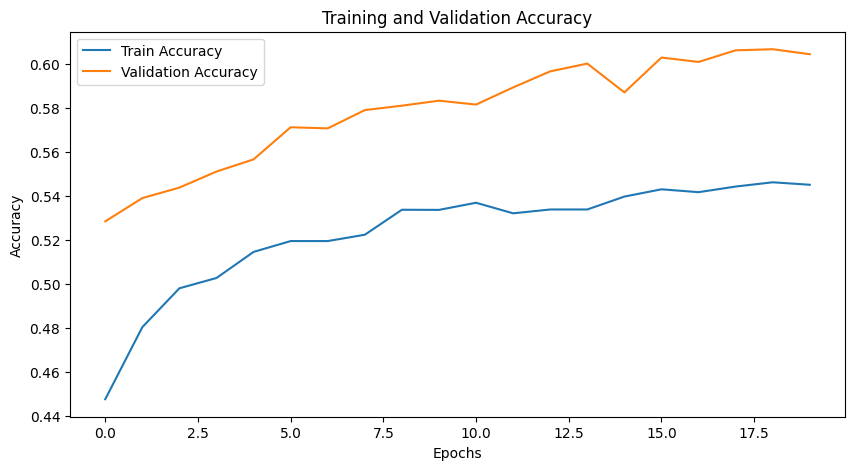

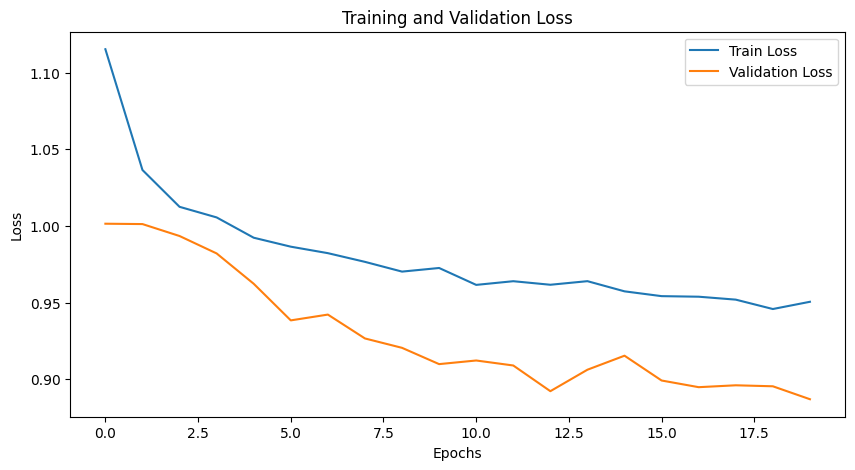

In [ ]:
import matplotlib.pyplot as plt

# Plot Training & Validation Accuracy
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

# Plot Training & Validation Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
# Unfreeze the base model for fine-tuning
base_model.trainable = True

# Compile with a lower learning rate to prevent large changes
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Fine-tune the model for additional epochs
fine_tune_epochs = 15  # Adjust epochs if necessary
history_fine_tune = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=fine_tune_epochs,
    batch_size=32,
    verbose=1
)

model.save("/content/emotion_model_mobilenetv2.h5")
print("Model saved successfully!")

Epoch 1/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 280s 466ms/step - accuracy: 0.7501 - loss: 0.5751 - val_accuracy: 0.7492 - val_loss: 0.5582
Epoch 2/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 206s 411ms/step - accuracy: 0.7658 - loss: 0.5528 - val_accuracy: 0.7658 - val_loss: 0.5381
Epoch 3/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 205s 408ms/step - accuracy: 0.7642 - loss: 0.5406 - val_accuracy: 0.7620 - val_loss: 0.5450
Epoch 4/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 210s 419ms/step - accuracy: 0.7738 - loss: 0.5278 - val_accuracy: 0.7514 - val_loss: 0.5581
Epoch 5/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 208s 413ms/step - accuracy: 0.7768 - loss: 0.5191 - val_accuracy: 0.7519 - val_loss: 0.5627
Epoch 6/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 208s 414ms/step - accuracy: 0.7860 - loss: 0.5037 - val_accuracy: 0.7748 - val_loss: 0.5280
Epoch 7/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 206s 409ms/step - accuracy: 0.7897 - loss: 0.4879 - val_accuracy: 0.7653 - val_loss: 0.5361
Epoch 8/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 211s 421ms/step - accuracy: 0.7928 -

Model saved successfully!


In [ ]:
import os
print(os.path.exists("/content/emotion_model_mobilenetv2.h5"))


True


In [ ]:
from google.colab import files
files.download("emotion_model_mobilenetv2.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>